<a href="https://colab.research.google.com/github/ParvJain108/EE604_Image_Processing/blob/main/EE604_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bit-Plane Slicing and Progressive Image Reconstruction**
---

1. Image Setup

--2026-08-13 12:49:24--  https://github.com/ParvJain108/EE604_Image_Processing/blob/main/HW1/image.jpg?raw=true
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/ParvJain108/EE604_Image_Processing/raw/refs/heads/main/HW1/image.jpg [following]
--2026-08-13 12:49:25--  https://github.com/ParvJain108/EE604_Image_Processing/raw/refs/heads/main/HW1/image.jpg
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ParvJain108/EE604_Image_Processing/refs/heads/main/HW1/image.jpg [following]
--2026-08-13 12:49:25--  https://raw.githubusercontent.com/ParvJain108/EE604_Image_Processing/refs/heads/main/HW1/image.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubuserc

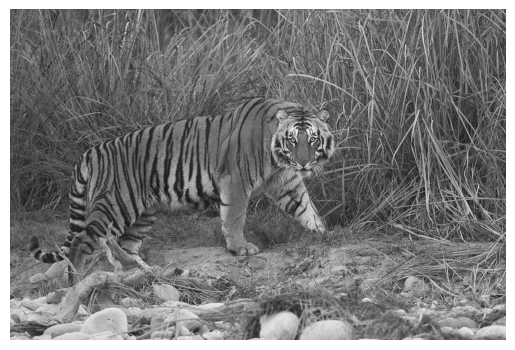

In [36]:
#link to github repository where image is stored
!wget -O image.jpg "https://github.com/ParvJain108/EE604_Image_Processing/blob/main/HW1/image.jpg?raw=true"

import cv2 #OpenCV Python
import matplotlib.pyplot as plt #pyplot module in matplotlib
import numpy as np #numpy

img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE) #Reading image and storing intensity values in array

#Shape of image in terms of pixels (width, length)
print(img.shape)

#Checking for data type of pixel storage (must be uint8)
print(img.dtype)

#Display image
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

2. Bit Plane Slicing and Progressive Image Reconstruction

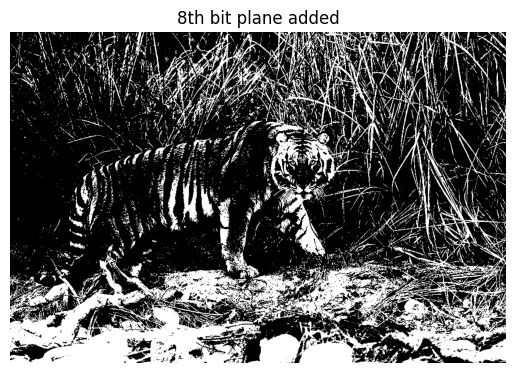

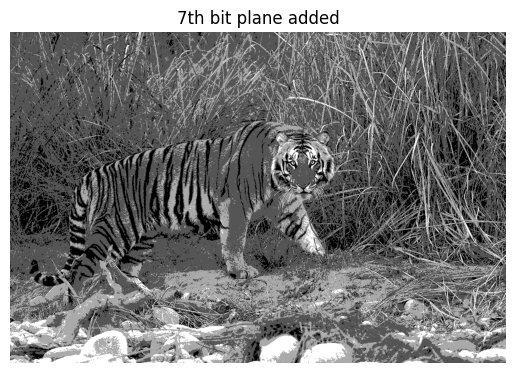

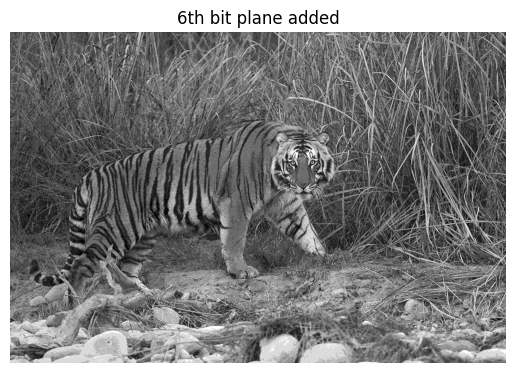

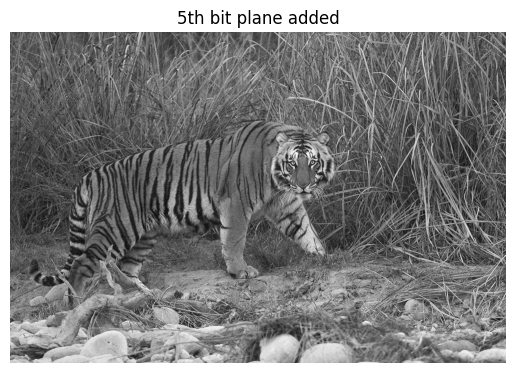

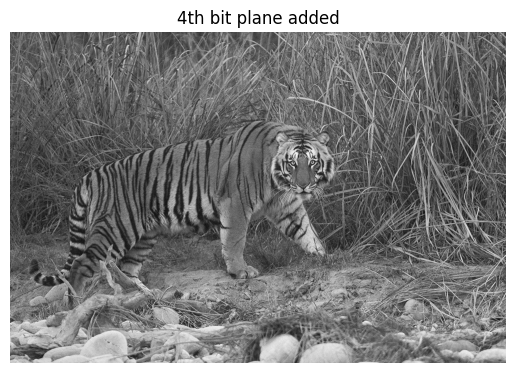

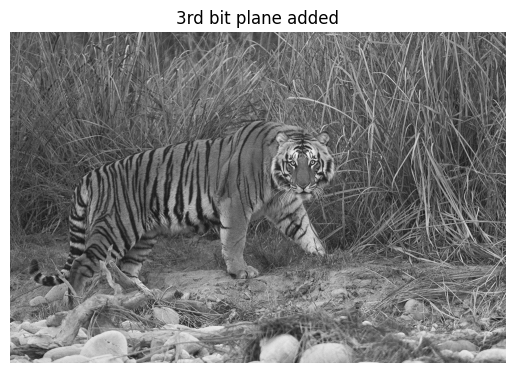

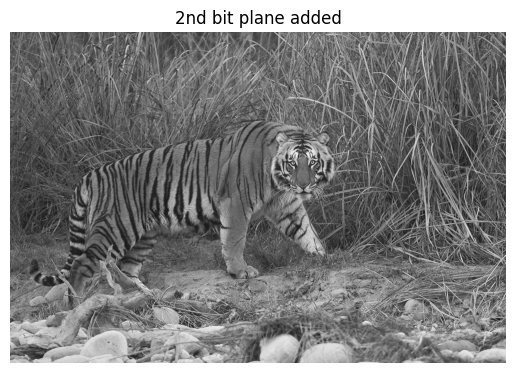

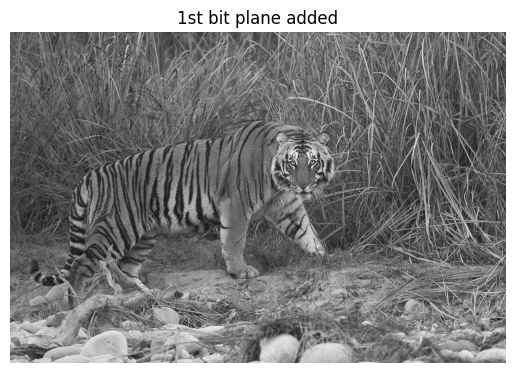

In [37]:
#Video parameters
fps = 2  #frames per second in the output video file
hold_seconds = 1  #how long each of the 8 stages stays visible
frames_per_stage = fps * hold_seconds

height, width = img.shape
video_path = 'Resultant_Video.mp4'

#VideoWriter setup: codec, fps, frame size (width, height)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_path, fourcc, fps, (width, height), isColor=False)

#Loop through each bit plane from MSB (7) to LSB (0)
#Ensure no garbage value in first iteration of loop
result_image = np.zeros_like(img)

#Loop
for i in range(7, -1, -1):

    # Extract the (i+1)-th bit plane and then right shift by i to bring the (i+1)-th bit to the LSB position, then bitwise-AND with 1 to get either 0 or 1
    # Result Image is the Progressive Image Reconstruction result after each plane addition to previous step after multiplication with weight of the bit plane
    result_image += ((img >> i) & 1)*(2**i)

    #Save frame for video file
    frame = result_image.astype(np.uint8)
    cv2.imwrite(f'stage_{8-i}_raw.png', frame)

    # Display bit plane
    plt.imshow(result_image, cmap='gray')
    if i > 2:
        plt.title( f'{i+1}th bit plane added')
    elif i == 2:
        plt.title( f'{i+1}rd bit plane added')
    elif i == 1:
        plt.title( f'{i+1}nd bit plane added')
    else:
        plt.title( f'{i+1}st bit plane added')
    plt.axis('off')

    #Save image
    plt.savefig(f'stage_{8-i}_annotated.png', bbox_inches='tight')

    plt.show()

    # Write to video (held for frames_per_stage frames)
    for _ in range(frames_per_stage):
        out.write(frame)

3. Video Details

In [38]:
import os
print(os.path.getsize('Resultant_Video.mp4'), "bytes")
print(f"Video frame rate: {fps} fps")
print(f"Each stage held for: {hold_seconds} seconds")
print(f"Frames per stage: {frames_per_stage}")
print(f"Total video duration: {8 * hold_seconds} seconds")

1701193 bytes
Video frame rate: 2 fps
Each stage held for: 1 seconds
Frames per stage: 2
Total video duration: 8 seconds
